In [30]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.data import Dataset
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [33]:
import warnings
warnings.filterwarnings("ignore")

# Data preparation

In [20]:
images_path = '/kaggle/input/dog-and-cat-detection/images'
annotations_path = '/kaggle/input/dog-and-cat-detection/annotations'

data = []

for xml_file in os.listdir(annotations_path):
    if xml_file.endswith('.xml'):
        tree = ET.parse(os.path.join(annotations_path, xml_file))
        root = tree.getroot()
        
        filename = root.find('filename').text
        width = int(root.find('size/width').text)
        height = int(root.find('size/height').text)

        obj = root.find('object')
        label = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)

        data.append([filename, width, height, label, xmin, ymin, xmax, ymax])

df = pd.DataFrame(data, columns=['filename', 'width', 'height', 'class', 'xmin', 'ymin', 'xmax', 'ymax'])
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,Cats_Test2888.png,313,310,cat,99,34,238,183
1,Cats_Test1617.png,500,417,dog,183,92,291,259
2,Cats_Test83.png,500,375,dog,155,119,356,250
3,Cats_Test899.png,500,375,dog,193,85,305,179
4,Cats_Test1204.png,500,334,dog,284,58,363,128


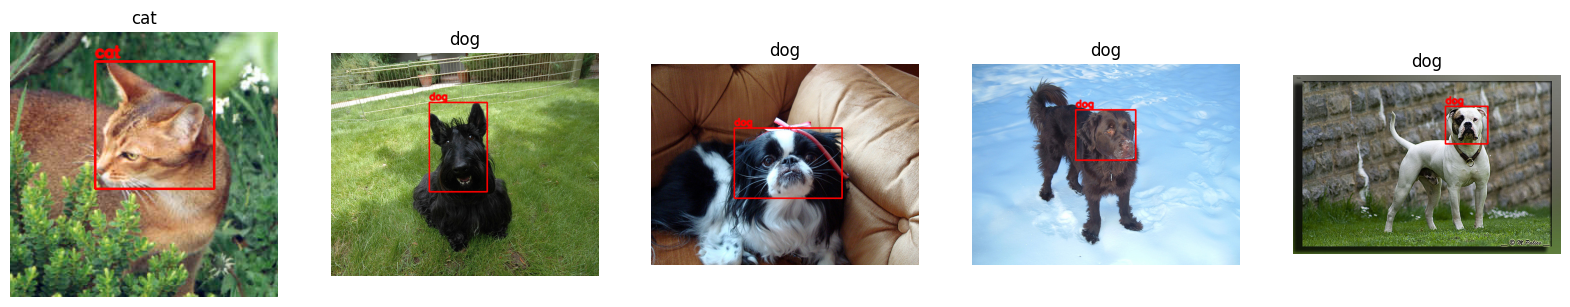

In [21]:
sample_df = df.head()
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(images_path, row['filename'])
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

    cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    cv2.putText(image, row["class"], (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 
                0.6, (255, 0, 0), 2, cv2.LINE_AA)

    axes[i].imshow(image)
    axes[i].axis("off")
    axes[i].set_title(row["class"])

plt.show()

In [22]:
target_width = 128
target_height = 128

def scale_bboxes(row):
    scale_x = target_width / row['width']
    scale_y = target_height / row['height']
    
    row['xmin'] = int(row['xmin'] * scale_x)
    row['ymin'] = int(row['ymin'] * scale_y)
    row['xmax'] = int(row['xmax'] * scale_x)
    row['ymax'] = int(row['ymax'] * scale_y)
    row['width'] = target_width
    row['height'] = target_height
    return row

df = df.apply(scale_bboxes, axis=1)
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,Cats_Test2888.png,128,128,cat,40,14,97,75
1,Cats_Test1617.png,128,128,dog,46,28,74,79
2,Cats_Test83.png,128,128,dog,39,40,91,85
3,Cats_Test899.png,128,128,dog,49,29,78,61
4,Cats_Test1204.png,128,128,dog,72,22,92,49


In [23]:
df["class"] = df["class"].astype("category").cat.codes
df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,Cats_Test2888.png,128,128,0,40,14,97,75
1,Cats_Test1617.png,128,128,1,46,28,74,79
2,Cats_Test83.png,128,128,1,39,40,91,85
3,Cats_Test899.png,128,128,1,49,29,78,61
4,Cats_Test1204.png,128,128,1,72,22,92,49


In [24]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [25]:
class ObjectDetectionGenerator(Sequence):
    def __init__(self, df, img_dir, batch_size=32, target_size=(128, 128), shuffle=True):
        self.df = df
        self.img_dir = img_dir
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_df = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size]
        images, bboxes, labels = [], [], []
        
        for _, row in batch_df.iterrows():
            img_path = os.path.join(self.img_dir, row['filename'])
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, self.target_size).astype(np.float32) / 255.0

            bbox = np.array([row['xmin'], row['ymin'], row['xmax'], row['ymax']], dtype=np.float32)
            label = np.array([row['class']], dtype=np.float32)

            images.append(image)
            bboxes.append(bbox)
            labels.append(label)

        return tf.convert_to_tensor(np.array(images)), {
            "bbox": tf.convert_to_tensor(np.array(bboxes)), 
            "class": tf.convert_to_tensor(np.array(labels))
        }

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

In [26]:
train_gen = ObjectDetectionGenerator(train_df, images_path)
val_gen = ObjectDetectionGenerator(val_df, images_path)
test_gen = ObjectDetectionGenerator(test_df, images_path, shuffle=False)

# Model building

In [27]:
input_shape = (128, 128, 3)
backbone = ResNet50(weights="imagenet", include_top=False, input_shape=input_shape)

x = Flatten()(backbone.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

bbox_output = Dense(4, activation='relu', name="bbox")(x)
class_output = Dense(1, activation='sigmoid', name="class")(x)

model = Model(inputs=backbone.input, outputs=[bbox_output, class_output])

model.compile(optimizer=Adam(learning_rate=1e-4), 
              loss={"bbox": "mse", "class": "binary_crossentropy"}, 
              metrics={"bbox": "mae", "class": "accuracy"})

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 134, 134, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 64, 64, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 64, 64, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 64, 64, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 66, 66, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 32, 32, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 32, 32, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 32, 32, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 32, 32, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 32, 32, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 32, 32, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 32, 32, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 31,977,861 (121.99 MB)

 Trainable params: 31,924,741 (121.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_reduce = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

history = model.fit(train_gen, validation_data=val_gen, epochs=50, callbacks=[early_stop, lr_reduce])

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


73/73 ━━━━━━━━━━━━━━━━━━━━ 125s 763ms/step - bbox_loss: 1376.5402 - bbox_mae: 27.9026 - class_accuracy: 0.6031 - class_loss: 3.4833 - loss: 1380.0236 - val_bbox_loss: 1473.5444 - val_bbox_mae: 31.3414 - val_class_accuracy: 0.6597 - val_class_loss: 1.0163 - val_loss: 1474.5607 - learning_rate: 1.0000e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 29s 367ms/step - bbox_loss: 254.5869 - bbox_mae: 12.2387 - class_accuracy: 0.6207 - class_loss: 3.6140 - loss: 258.2009 - val_bbox_loss: 1213.0377 - val_bbox_mae: 28.1459 - val_class_accuracy: 0.6580 - val_class_loss: 1.7634 - val_loss: 1214.8013 - learning_rate: 1.0000e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 351ms/step - bbox_loss: 194.0785 - bbox_mae: 10.7338 - class_accuracy: 0.6447 - class_loss: 3.4168 - loss: 197.4952 - val_bbox_loss: 1228.6853 - val_bbox_mae: 28.1994 - val_class_accuracy: 0.6580 - val_class_loss: 1.0929 - val_loss: 1229.7784 - learning_rate: 1.0000e-04
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 28s 354ms/step - bbox_loss: 173

# Examination of the results

In [35]:
def plot_history(accuracy, val_acuracy, loss, val_loss): 
    fig, axs= plt.subplots(2, 1, figsize=(12, 12))
    sns.lineplot(history.history[accuracy], ax= axs[0], label=accuracy, marker="o")
    sns.lineplot(history.history[val_acuracy],ax= axs[0], label=val_acuracy, marker="o")
    
    sns.lineplot(history.history[loss], ax= axs[1], label=loss, marker="o")
    sns.lineplot(history.history[val_loss], ax= axs[1], label=val_loss, marker="o")
      
    for ax in axs:
        ax.set_xticks(range(len(history.history['class_accuracy'])))
        ax.set_xticklabels(range(1, len(history.history['class_accuracy']) + 1))
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid()
    plt.show()

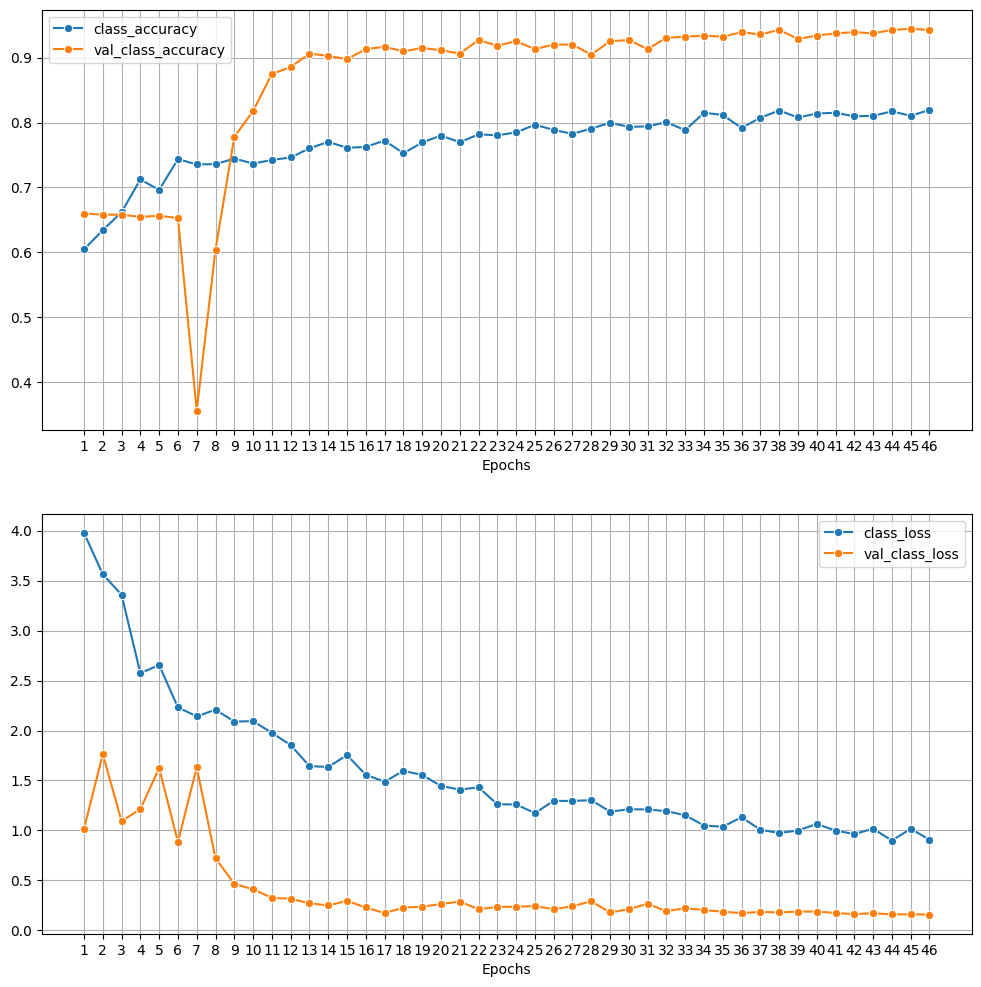

In [36]:
plot_history("class_accuracy", "val_class_accuracy", "class_loss", "val_class_loss")

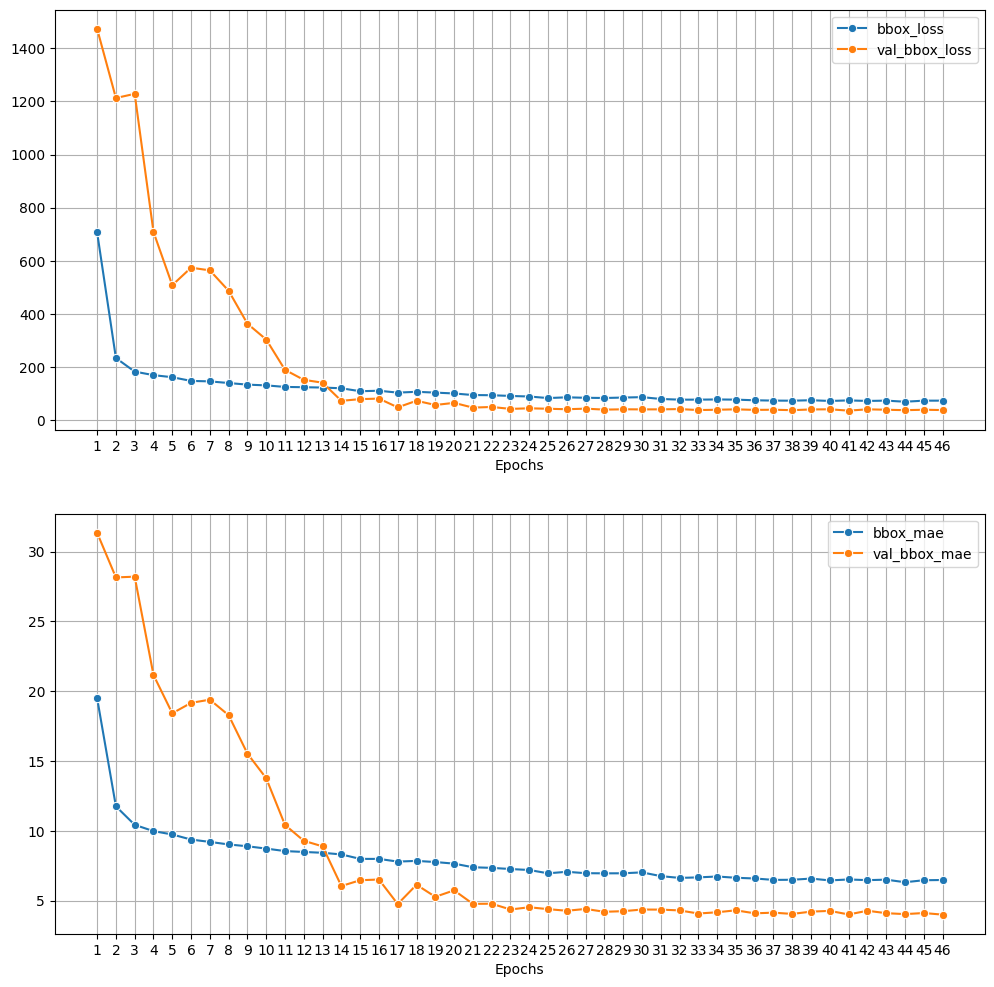

In [37]:
plot_history("bbox_loss", "val_bbox_loss", "bbox_mae", "val_bbox_mae")

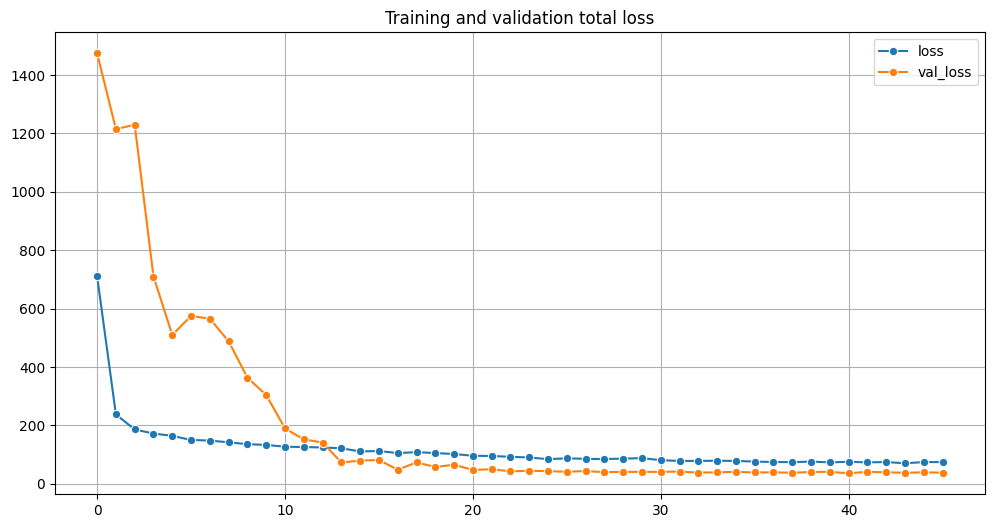

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(history.history["loss"], label="loss", marker="o")
sns.lineplot(history.history["val_loss"], label="val_loss", marker="o")

plt.title("Training and validation total loss")
plt.legend()
plt.grid()
plt.show()

In [45]:
test_results = model.evaluate(test_gen)
print("Test results:", test_results)

23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 605ms/step - bbox_loss: 35.7984 - bbox_mae: 4.1283 - class_accuracy: 0.9580 - class_loss: 0.1268 - loss: 35.9252
Test results: [36.291175842285156, 36.149452209472656, 0.14173178374767303, 4.07051944732666, 0.9551630616188049]


In [64]:
bbox_preds, class_preds = model.predict(batch_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


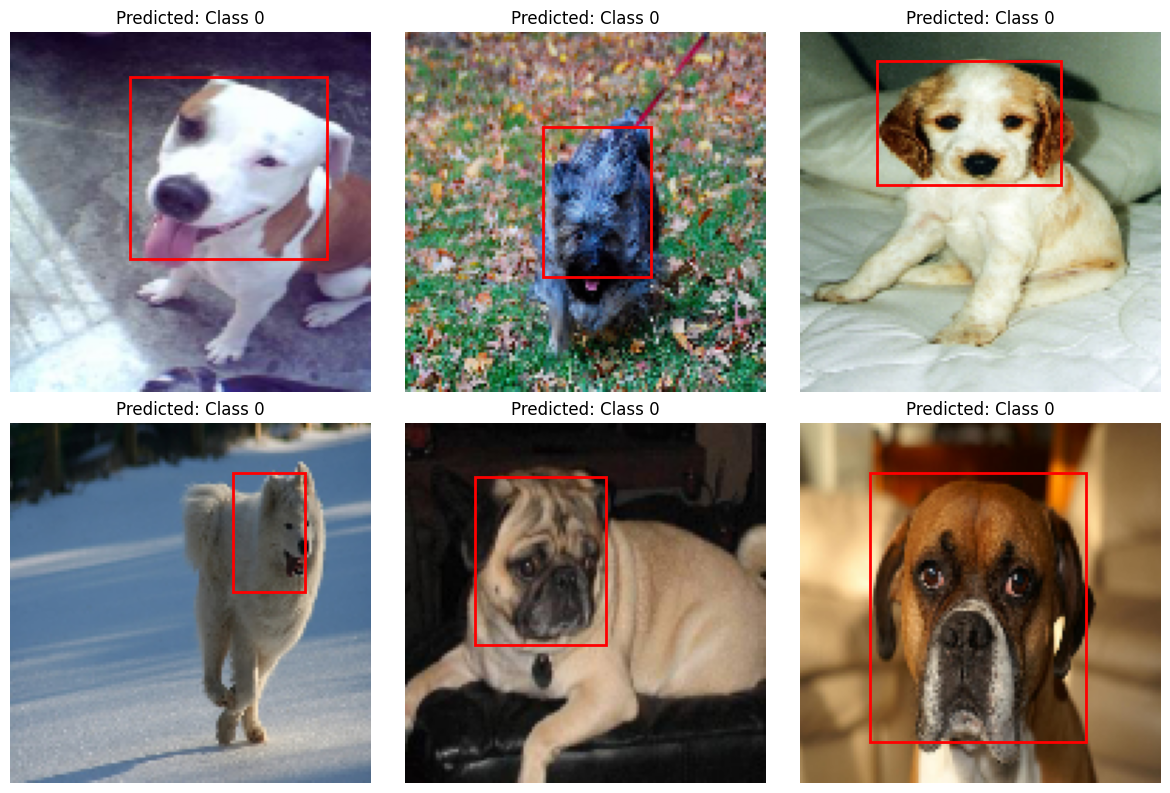

In [63]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for i in range(6):
    bbox = bbox_preds[i]
    class_pred = class_preds[i]

    image = batch_images[i]
    image_height, image_width, _ = image.shape

    xmin, ymin, xmax, ymax = bbox
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(image_width, xmax)
    ymax = min(image_height, ymax)

    ax = axes[i]
    ax.imshow(image)
    ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, linewidth=2, 
                               edgecolor='r', facecolor='none'))

    class_name = "Class {}".format(int(class_pred))
    ax.set_title(f"Predicted: {class_name}")
    
    ax.axis('off')

plt.tight_layout()
plt.show()

In [72]:
def compute_iou(bbox_pred, bbox_gt):
    xmin_pred, ymin_pred, xmax_pred, ymax_pred = bbox_pred
    xmin_gt, ymin_gt, xmax_gt, ymax_gt = bbox_gt
    
    intersection_xmin = max(xmin_pred, xmin_gt)
    intersection_ymin = max(ymin_pred, ymin_gt)
    intersection_xmax = min(xmax_pred, xmax_gt)
    intersection_ymax = min(ymax_pred, ymax_gt)
    
    if intersection_xmax < intersection_xmin or intersection_ymax < intersection_ymin:
        return 0.0
    
    intersection_area = (intersection_xmax - intersection_xmin) * (intersection_ymax - intersection_ymin)
    
    bbox_area_pred = (xmax_pred - xmin_pred) * (ymax_pred - ymin_pred)
    bbox_area_gt = (xmax_gt - xmin_gt) * (ymax_gt - ymin_gt)
    
    union_area = bbox_area_pred + bbox_area_gt - intersection_area
    
    iou = intersection_area / union_area
    return iou

ious = []
for i in range(len(batch_images)):
    bbox_pred = bbox_preds[i]
    bbox_gt = batch_labels['bbox'][i]
    
    iou = compute_iou(bbox_pred, bbox_gt)
    ious.append(iou)

mean_iou = sum(ious) / len(ious)
print(f"Mean IoU value: {mean_iou}")
print(f"Max IoU value: {np.max(ious)}")
print(f"Min IoU value: {np.min(ious)}")

Mean IoU value: 0.7311469912528992
Max IoU value: 0.9266375303268433
Min IoU value: 0.18280136585235596
